In [37]:
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv("../../raw/s&p500/sp500.csv")
df.head(10)

,Date,Close,High,Low,Open,Volume
0,2006-01-03,1268.800049,1270.219971,1245.739990,1248.290039,2554570000
1,2006-01-04,1273.459961,1275.369995,1267.739990,1268.800049,2515330000
2,2006-01-05,1273.479980,1276.910034,1270.300049,1273.459961,2433340000
3,2006-01-06,1285.449951,1286.089966,1273.479980,1273.479980,2446560000
4,2006-01-09,1290.150024,1290.780029,1284.819946,1285.449951,2301490000
5,2006-01-10,1289.689941,1290.150024,1283.760010,1290.150024,2373080000
6,2006-01-11,1294.180054,1294.900024,1288.119995,1289.719971,2406130000
7,2006-01-12,1286.060059,1294.180054,1285.040039,1294.180054,2318350000
8,2006-01-13,1287.609985,1288.959961,1282.780029,1286.060059,2206510000
9,2006-01-17,1282.930054,1287.609985,1278.609985,1287.609985,2179970000


In [39]:
for col in df.columns:
    n_missing = df[col].isna().sum()
    pct_missing = round(n_missing / len(df[col]) * 100, 2)
    print(f"{col}: {n_missing} missing ({pct_missing}%)")
    

Date: 0 missing (0.0%)
Close: 0 missing (0.0%)
High: 0 missing (0.0%)
Low: 0 missing (0.0%)
Open: 0 missing (0.0%)
Volume: 0 missing (0.0%)


In [40]:
df['Date'] = pd.to_datetime(df['Date'])

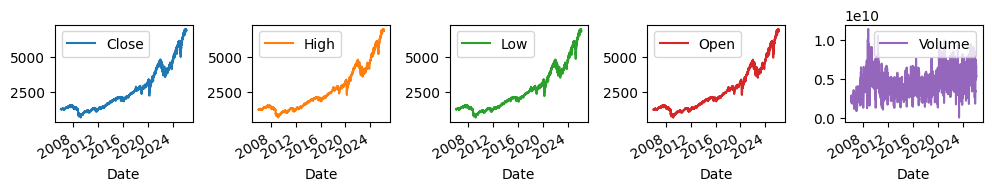

In [41]:
df.set_index("Date").plot(subplots=True, layout=(6, 6), figsize=(12, 10))
plt.tight_layout()
plt.show()

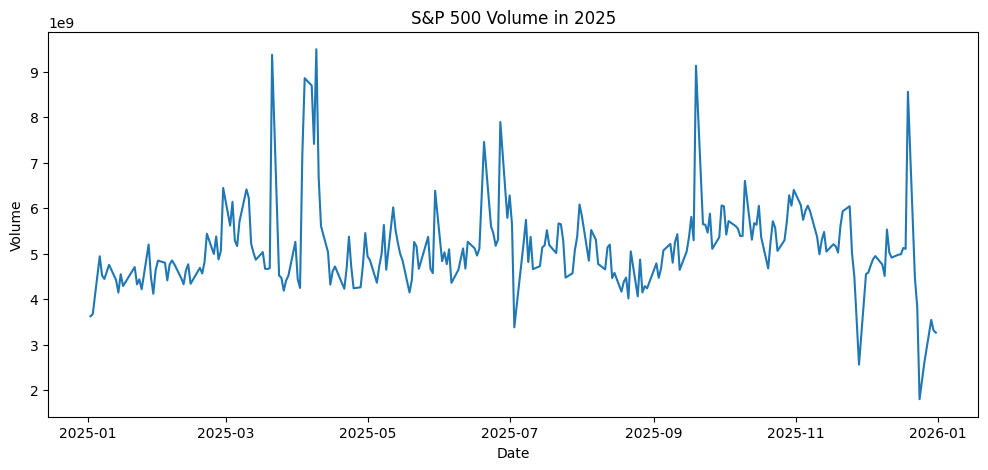

In [42]:
# Filter alle rijen van 2008
year = 2025
df_2008 = df[df['Date'].dt.year == year]

# Plot
plt.figure(figsize=(12,5))
plt.plot(df_2008['Date'], df_2008['Volume'])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title(f'S&P 500 Volume in {year}')
plt.show()

## feature engineering

* return → dagelijkse beweging
* high_low_pct → volatiliteit
* open_close_pct → intraday beweging
* volume_change → verandering in handelsvolume

In [43]:
df["return"] = df["Close"].pct_change()
df["high_low_pct"] = (df["High"] - df["Low"]) / df["Low"]
df["open_close_pct"] = (df["Close"] - df["Open"]) / df["Open"]
df["volume_change"] = df["Volume"].pct_change()

* Rolling features

In [44]:
df["MA5"] = df["Close"].rolling(5).mean()
df["MA10"] = df["Close"].rolling(10).mean()
df["Volatility5"] = df["return"].rolling(5).std()

In [45]:
df = df.dropna().reset_index(drop=True)

In [46]:
df.size

65793

In [47]:
df.head(10)

,Date,Close,High,Low,Open,Volume,return,high_low_pct,open_close_pct,volume_change,MA5,MA10,Volatility5
0,2006-01-17,1282.930054,1287.609985,1278.609985,1287.609985,2179970000,-0.003635,0.007039,-0.003635,-0.012028,1288.094019,1283.181006,0.003875
1,2006-01-18,1277.930054,1282.930054,1272.079956,1282.930054,2233200000,-0.003897,0.008529,-0.003897,0.024418,1285.742041,1284.094006,0.004022
2,2006-01-19,1285.040039,1287.790039,1277.930054,1277.930054,2444020000,0.005564,0.007716,0.005564,0.094403,1283.914038,1285.252014,0.004750
3,2006-01-20,1261.489990,1285.040039,1260.920044,1285.040039,2845810000,-0.018326,0.019129,-0.018326,0.164397,1279.000024,1284.053015,0.008997
4,2006-01-23,1263.819946,1268.189941,1261.489990,1261.489990,2256070000,0.001847,0.005311,0.001847,-0.207231,1274.242017,1281.890015,0.009091
5,2006-01-24,1266.859985,1271.469971,1263.819946,1263.819946,2608720000,0.002405,0.006053,0.002405,0.156312,1271.028003,1279.561011,0.009492
6,2006-01-25,1264.680054,1271.869995,1259.420044,1266.859985,2617060000,-0.001721,0.009885,-0.001721,0.003197,1268.378003,1277.060022,0.009461
7,2006-01-26,1273.829956,1276.439941,1264.680054,1264.680054,2856780000,0.007235,0.009299,0.007235,0.091599,1266.135986,1275.025012,0.009820
8,2006-01-27,1283.719971,1286.380005,1273.829956,1273.829956,2623620000,0.007764,0.009852,0.007764,-0.081616,1270.581982,1274.791003,0.003979
9,2006-01-30,1285.189941,1287.939941,1283.510010,1283.719971,2282730000,0.001145,0.003451,0.001145,-0.129931,1274.855981,1274.548999,0.004063


In [48]:
import numpy as np

# Alles wat oneindig of absurd groot/klein is vervangen door 0
df["volume_change"] = df["volume_change"].replace([np.inf, -np.inf], np.nan)  # eerst inf → NaN
df["volume_change"] = df["volume_change"].fillna(0)                            # NaN → 0

# Extra check: extreem grote waarden (optioneel)
threshold = 1e6  # alles groter dan 1 miljoen of kleiner dan -1 miljoen
df.loc[df["volume_change"].abs() > threshold, "volume_change"] = 0

In [49]:
df.to_csv("../../processed/s&p500/sp500_processed.csv", index=False)